We will explore the physics of two driven dissipative cavities that are dispersively coupled. There will be a boolean control button to turn on and off the drives. The Hamiltonian of the system will read 
$$  
H = \Delta_a a^{\dagger}a  + \Delta_b b^{\dagger}b - \chi_{ab} \, a^{\dagger}a  b^{\dagger} b + \zeta_a (a + a^{\dagger}) +  \zeta_b (b + b^{\dagger})
$$  
where $a$ and $b$ are the two almost linear field modes (or two cavities) that are dispersively coupled with cross-kerr $\chi_{ab}$ and the respective drives are applied at drive amplitudes $\zeta_a$, $\zeta_{b}$ and detunnings $\Delta_a$ and $\Delta_b$, respectively.    

In [201]:

import dynamiqs as dq
import jax.numpy as jnp
import pathlib as path
import json
import matplotlib.pyplot as plt

# Define Truncation of the field modes
N_a = 25
N_b = 25


__1.a The Cavity Relaxation (Undriven and driven)__\
    The equation of motion of the two mode system reads 
    $$ \frac{d\rho}{dt} = -i [H,\rho] +  \mathcal{L}(a) \rho +  \mathcal{L}(b) \rho , ~~~\text{with}~ \mathcal{L}(X) \rho = \kappa_X \left( X \rho X^{\dagger} - \frac{1}{2}\{X^{\dagger}X,\rho \} \right) $$ 
    where in the simulation we will always stack mode a first and then mode b

In [ ]:
# Define the system parameters (all freqs are in MHz and all times are in microseconds)
Delta_a =  0.1
Delta_b = 0.1
chi_ab = 0.1
kappa_a = 0.1
kappa_b = 50*kappa_a
Ea = 0.2
Eb = 0.2

drive = True

# Define the system operators : 
a = dq.destroy(N_a);  a = dq.tensor(a, dq.eye(N_b))
b = dq.destroy(N_b);  b = dq.tensor(dq.eye(N_a), b)

# Define the system Hamiltonian
H = 2*jnp.pi* (Delta_a * a.dag() @ a + Delta_b * b.dag() @ b - chi_ab * a.dag() @ a @ b.dag() @ b)
H_drive = 2*jnp.pi*(Ea * (a + a.dag()) + Eb * (b + b.dag()))

if drive : 
    H = H + H_drive

# Dfine the Jump Operators
Dissipators = [jnp.sqrt(kappa_a) * a, jnp.sqrt(kappa_b) * b] 


# Define the Observables
Observables = [a.dag() @ a, b.dag() @ b] 

In [203]:
# The Dynamical Parameters 
tmax = 10/min(kappa_a, kappa_b)
td = 5000
times = jnp.linspace(0, tmax, td)

# Define the Initial State
rho0 = dq.tensor(dq.fock_dm(N_a,2), dq.fock_dm(N_b,0))

# The Solver Parameters
method = dq.method.Tsit5(rtol=1e-6, atol=1e-8)

In [204]:
# Run the Simulation
result = dq.mesolve(H, Dissipators, rho0, tsave=times, exp_ops = Observables, method=method)
print(result)

# Extracting the results
#states_array = jnp.array([rho.to_jax() for rho in result.states])
#states1_array = jnp.array([rho.ptrace(0).to_jax() for rho in result.states])
#states2_array = jnp.array([rho.ptrace(1).to_jax() for rho in result.states])

#pops1 = jnp.real(jnp.diagonal(states1_array, axis1=1, axis2=2))
#pops2 = jnp.real(jnp.diagonal(states2_array, axis1=1, axis2=2))

#print(f" The states density matrices of the full system is stored as {jnp.shape(states_array)}")
#print(f"The density matrices and population vectors of A and B are stored as {jnp.shape(states1_array)}, {jnp.shape(states2_array)}, {jnp.shape(pops1)}, {jnp.shape(pops2)}")

|██████████| 100.0% ◆ elapsed 02m29s ◆ remaining 0.00ms  

==== MESolveResult ====
Method  : Tsit5
Infos   : 12275 steps (11764 accepted, 511 rejected)
States  : QArray complex64 (5000, 625, 625) | 14.6 Gb
Expects : Array complex64 (2, 5000) | 78.1 Kb


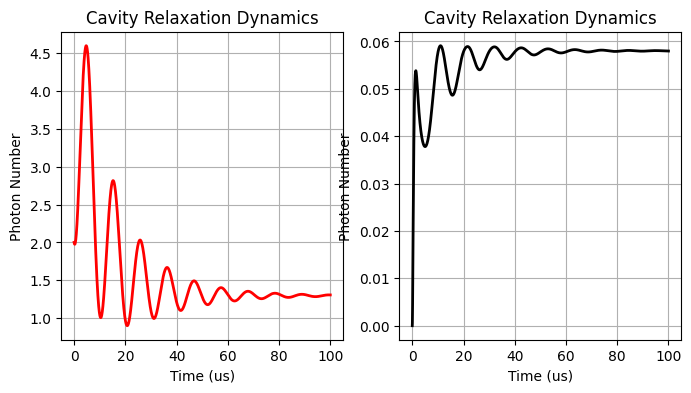

In [205]:
# Analyzing the results
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].plot(times, result.expects[0].real, linewidth=2, color = "r")
ax[0].set_xlabel("Time (us)")
ax[0].set_ylabel("Photon Number")
ax[0].set_title("Cavity Relaxation Dynamics")
ax[0].grid()


ax[1].plot(times, result.expects[1].real, linewidth=2, color = "k")
ax[1].set_xlabel("Time (us)")
ax[1].set_ylabel("Photon Number")
ax[1].set_title("Cavity Relaxation Dynamics")
ax[1].grid()